# (02) mnist + mlp

**Motivation**: host = ```yoru```, device = ```cuda:1``` <br>

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_iclr_ipvae'))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: yoru

## Poisson + MNIST + MLP

- recon: MSE
- Low t_train: 8
- Mid beta: 4/8

In [3]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs('MNIST', model_type, 'ngd|mlp')

t_train = 8

cfg_vae['t_train'] = t_train
cfg_vae['kl_beta'] = 4/8 * t_train

cfg_vae['track_stats'] = True

### Make model + trainer

In [4]:
model = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = Trainer(model, ConfigTrain(**cfg_tr), device=device)

tr.n_iters

120000

### Print info

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  567.1 K   |
|     ———     |    ———     |
|    layer    |  567.1 K   |
+-------------+------------+

poisson_MNIST_t-8_b-4_k-128_mse_<ngd|mlp>
b200-ep400-lr(0.002)_temp(0.05)_gr(50)_(2025_06_02,21:02)

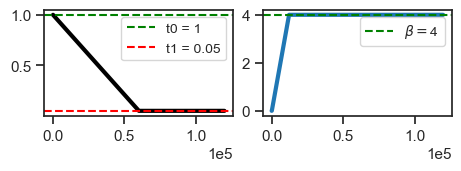

In [5]:
model.print()
tr.print()
tr.show_schedules()

In [6]:
model.layer.n_exp

tensor([50, 50, 50, 50, 50, 50, 50, 50], device='cuda:1', dtype=torch.int32)

In [7]:
model.cfg.track_stats

True

In [8]:
print(f"{vars(tr.model.cfg)}\n\n\n{vars(tr.cfg)}")

{'prior_log_dist': 'uniform', 'clamp_prior': -2, 't_train': 8, 'kl_beta': 4.0, 'n_latents': 128, 'enc_type': 'ngd',
'dec_type': 'mlp', 'recon_mode': 'mse', 'dataset': 'MNIST', 'dataset_name': 'MNIST', 'feeder': 'stationary', 
'feeder_cfg': {}, 'input_sz': (1, 28, 28), 'shape': (-1, 1, 28, 28), 'init_dist': 'normal', 'init_scale': 0.0001, 
'clamp_vals': {'u': (7.0,), 'du': (5.0,), 'dec': 3.45}, 'stochastic': True, 'fit_dec_var': False, 'fit_prior': 
True, 'seed': 0, 'track_stats': True, 'base_dir': '/home/hadi/Projects/PoissonVAE', 'data_dir': 
'/home/hadi/Datasets', 'runs_dir': '/home/hadi/Projects/PoissonVAE/runs/poisson_MNIST_t-8_b-4_k-128_mse_<ngd|mlp>',
'mods_dir': '/home/hadi/Projects/PoissonVAE/models/poisson_MNIST_t-8_b-4_k-128_mse_<ngd|mlp>', 'results_dir': 
'/home/hadi/Projects/PoissonVAE/results'}


{'lr': 0.002, 'epochs': 400, 'batch_size': 200, 'dataset_kws': None, 'warm_restart': 0, 'warmup_portion': 0.005, 
'optimizer': 'adamax_fast', 'optimizer_kws': {'weight_decay': 0.001, 'betas': (0.9, 0.999), 'eps': 1e-08}, 
'scheduler_type': 'cosine', 'scheduler_kws': {'T_max': 398.0, 'eta_min': 1e-05}, 'ema_rate': None, 'grad_clip': 50,
'chkpt_freq': 20, 'eval_freq': 20, 'log_freq': 10, 'kl_beta_min': 0.0001, 'kl_const_portion': 0.001, 
'kl_anneal_portion': 0.1, 'temp_anneal_portion': 0.5, 'temp_anneal_type': 'lin', 'temp_start': 1.0, 'temp_stop': 
0.05}

### Fit model

In [9]:
tr.train('gold')

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


Warning: Could not save code info: Reference at 'refs/heads/main' does not exist

Warning: Could not save notebook info: Can't identify the notebook path.

epoch # 400, avg loss: 26.986: 100%|████████| 400/400 [7:22:17<00:00, 66.34s/it]


**Task:** reproduce this while gradually updating the code

**Conclusion:** 

In [10]:
print(model.layer.n_exp)

tensor([10, 18, 25, 29, 31, 32, 33, 34], device='cuda:1', dtype=torch.int32)

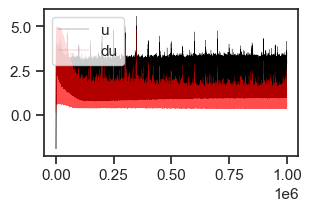

In [11]:
u_max = np.array(tr.model.stats['u_max'])
du_max = np.array(tr.model.stats['du_max'])

fig, ax = create_figure()
ax.plot(u_max, color='k', label='u', lw=0.2)
ax.plot(du_max, color='r', label='du', alpha=0.7, lw=0.2)
ax.legend()
plt.show()

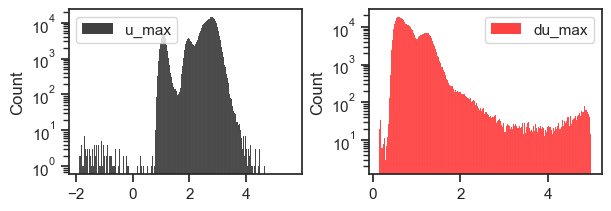

In [12]:
fig, axes = create_figure(1, 2)
sns.histplot(tr.model.stats['u_max'], color='k', label='u_max', ax=axes[0])
sns.histplot(tr.model.stats['du_max'], color='r', label='du_max', ax=axes[1])
for ax in axes.flat:
    ax.set(yscale='log')
add_legend(axes)
plt.show()

100%|███████████████████████████████████| 3/3 [00:07<00:00,  2.44s/it]


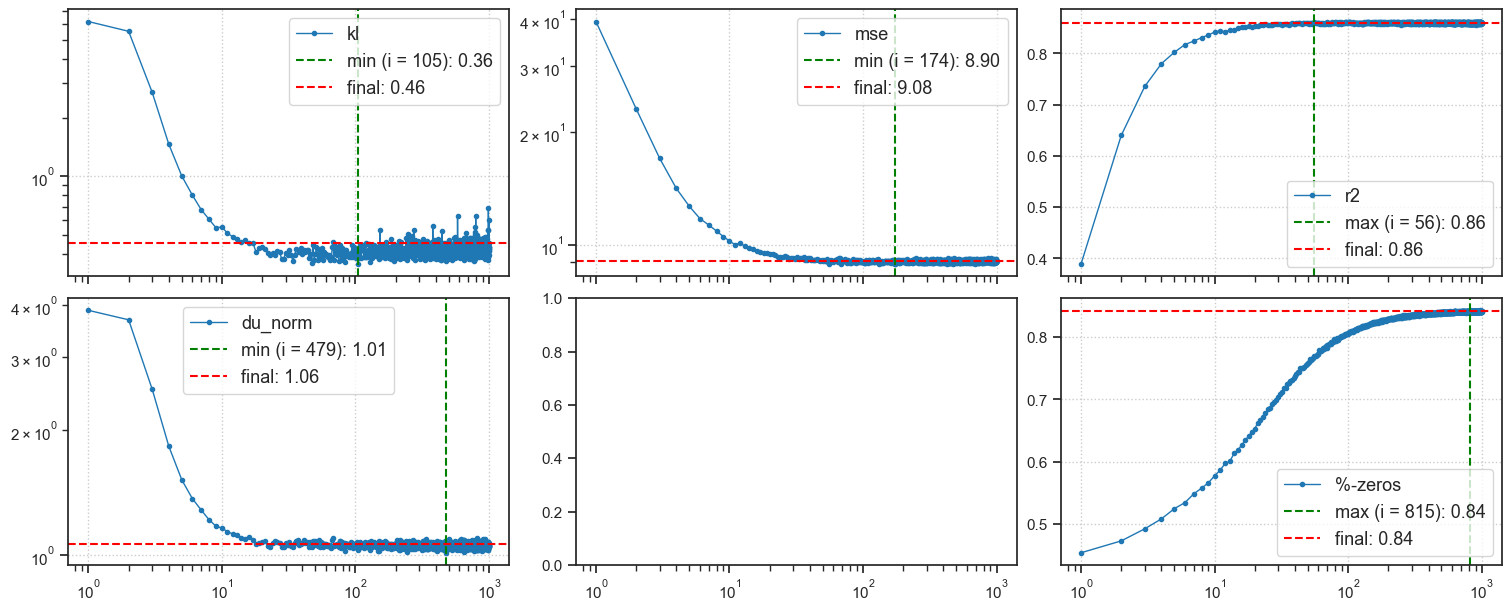

CPU times: user 8.94 s, sys: 68 ms, total: 9 s
Wall time: 8.99 s


In [36]:
%%time

kws = dict(

)
results = tr.analysis(
    dl='vld',
    t_total=1000,
    n_data_batches=3,
)
_ = plot_convergence(results, color='C0')

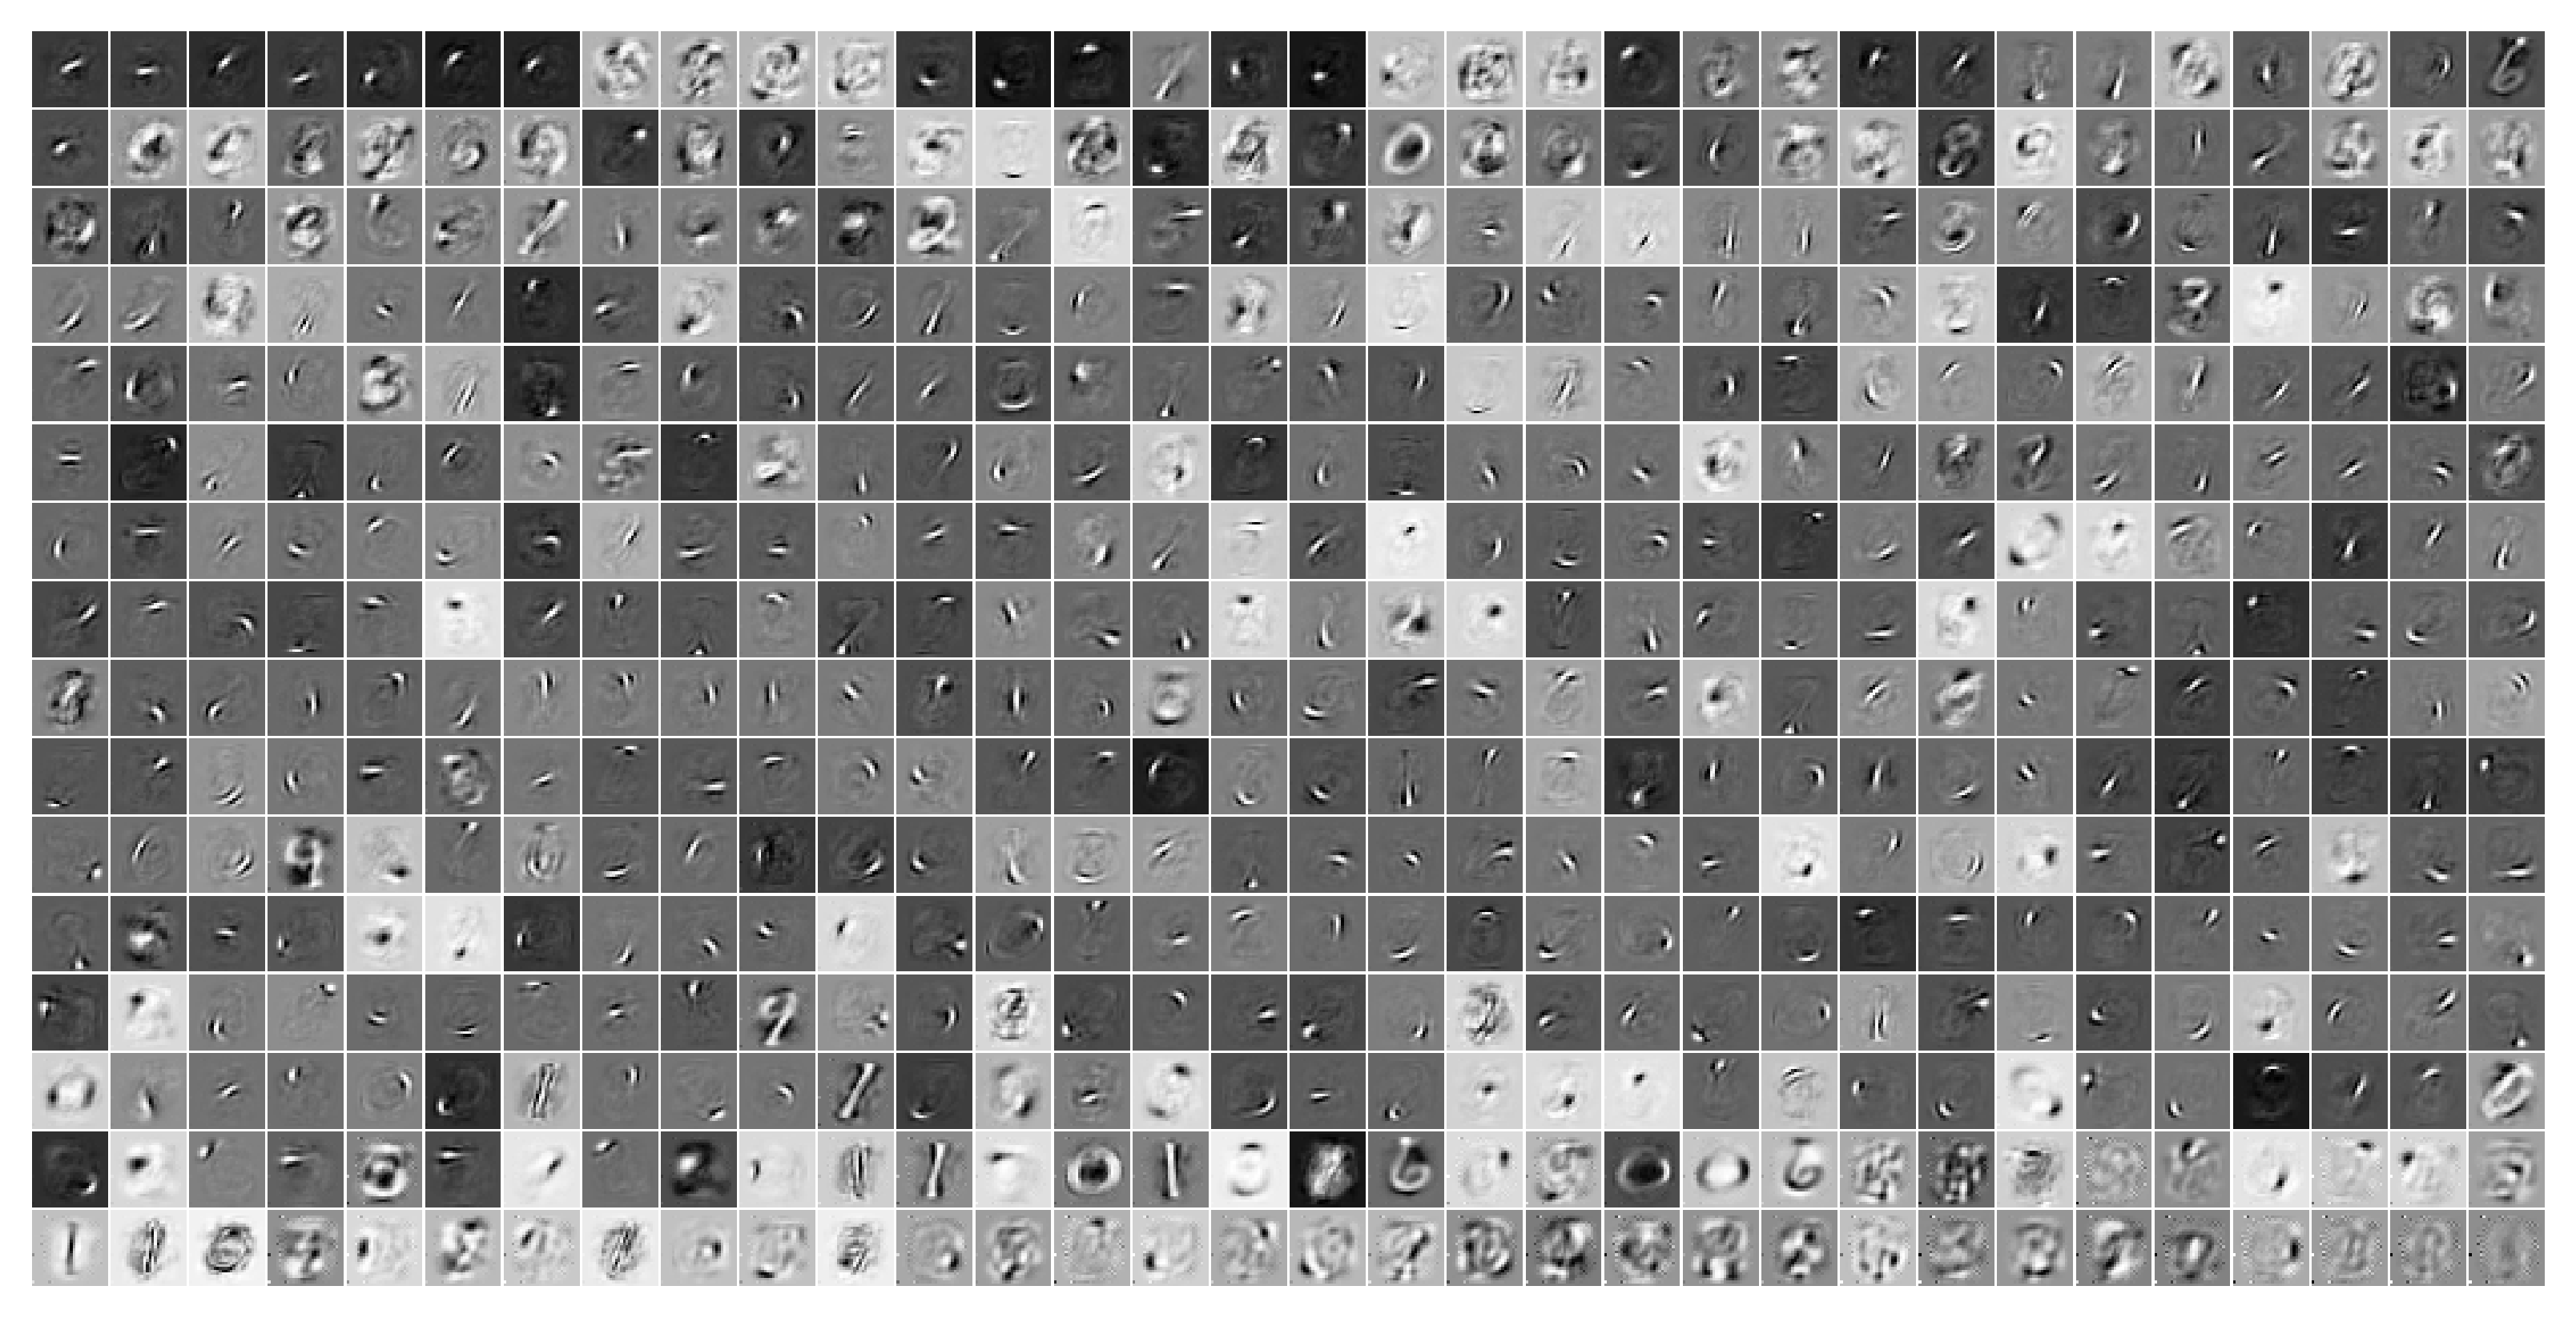

In [37]:
w = tr.model.layer.get_weight()
norms = tonp(torch.linalg.vector_norm(w, dim=1))
tr.model.show(order=np.argsort(norms), dpi=400, pad=1);

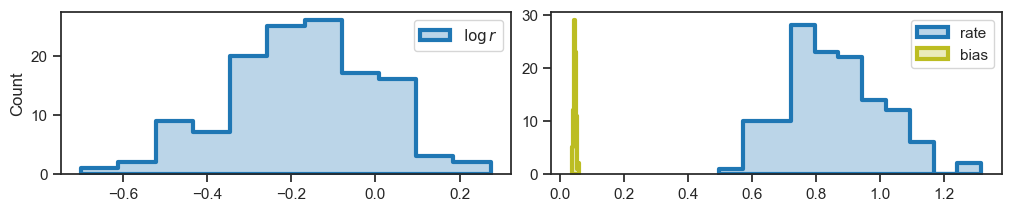

In [38]:
log_rate = tonp(tr.model.layer.u_init[0].squeeze())
bias = tonp(tr.model.layer.log_bias.exp().squeeze())

fig, axes = create_figure(1, 2, (10, 2))
kws = dict(fill=True, lw=3, alpha=0.3, ax=axes[0])
sns.histplot(log_rate, color='C0', element='step', label=r'$\log r$', **kws)

kws = dict(fill=True, lw=3, alpha=0.3, ax=axes[1])
sns.histplot(np.exp(log_rate), color='C0', element='step', label='rate', **kws)
sns.histplot(bias, color='C8', element='step', label='bias', **kws)

axes[1].set(ylabel='')
add_legend(axes)

plt.show()

In [39]:
dead = (log_rate < -1) | (log_rate > 2)
dead.sum(), (~dead).sum(), dead.sum() / len(dead)

(0, 128, 0.0)

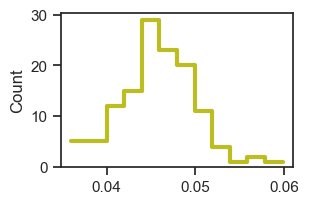

In [40]:
histplot(bias, color='C8', lw=3)
plt.show()

In [41]:
(bias > 0).mean()

1.0

In [42]:
bias[dead]

array([], dtype=float32)

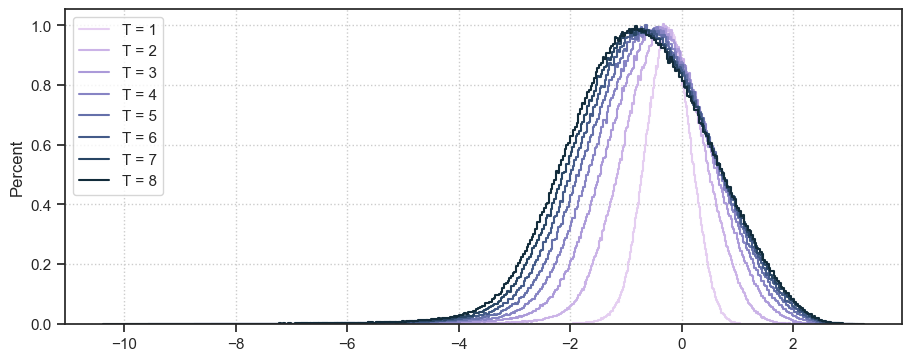

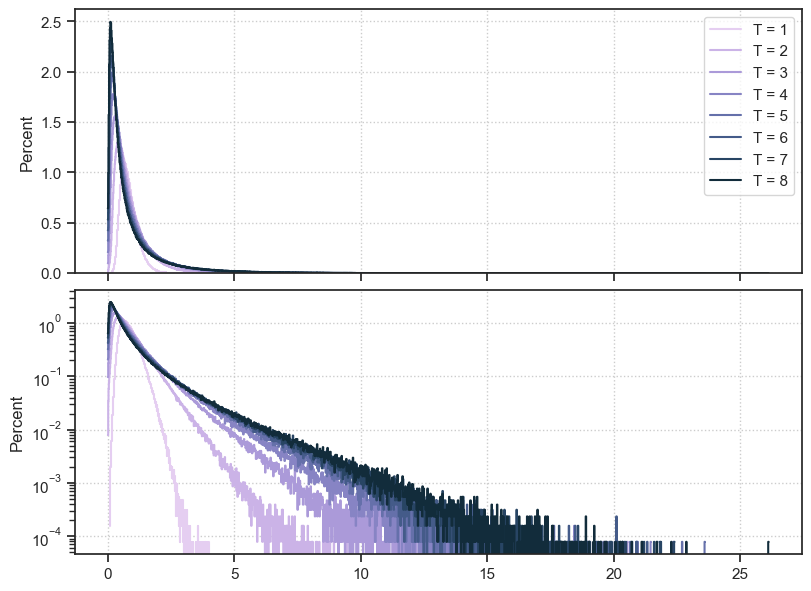

In [43]:
mult = 1

results = tr.xtract_ftr(
    t_total=tr.model.cfg.t_train * mult,
    save_freq=mult,
    n_data_batches=10,
    data_batch_sz=2000,
    verbose=False,
)


fig, ax = create_figure(1, 1, (9, 3.5))
pal = get_cubehelix_palette(len(results['times']), start=2.5)

for i, t in enumerate(results['times']):
    sns.histplot(
        results['state_0'][:, i].ravel(),
        stat='percent',
        element='step',
        fill=False,
        color=pal[i],
        label=f"T = {t}",
        ax=ax,
    )
ax.legend(loc='upper left')
ax.grid()
plt.show()


fig, axes = create_figure(2, 1, (8, 5.8), sharex='col')
for i, t in enumerate(results['times']):
    for ax in axes.flat:
        sns.histplot(
            np.exp(results['state_0'][:, i].ravel()),
            stat='percent',
            element='step',
            fill=False,
            color=pal[i],
            label=f"T = {t}",
            ax=ax,
        )
axes[0].legend()
axes[1].set(yscale='log')
add_grid(axes)
plt.show()

In [44]:
pal

[[0.8975507056831679, 0.8094812603307622, 0.9465577040964425],
 [0.79560472689218, 0.7025635211553574, 0.906794768375293],
 [0.6686407796183966, 0.6049991340541501, 0.8494437689559234],
 [0.5300158317387482, 0.5177020247219766, 0.7688253061707515],
 [0.3958415626832449, 0.4388270462167934, 0.6665458619228831],
 [0.26577992459661565, 0.3565507347057864, 0.5356429755155622],
 [0.158519102797742, 0.271866265196377, 0.39112323360373646],
 [0.07235872150128392, 0.17287618251766537, 0.23013648857700542]]

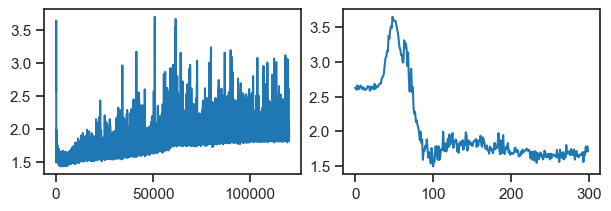

In [45]:
grad = np.array(list(tr.stats['grad'].values()))

fig, axes = create_figure(1, 2)
axes[0].plot(np.log(grad))
axes[1].plot(np.log(grad)[:300])
plt.show()

In [46]:
(grad > 100).sum()

0

100%|█████████████████████████████████| 50/50 [02:02<00:00,  2.46s/it]


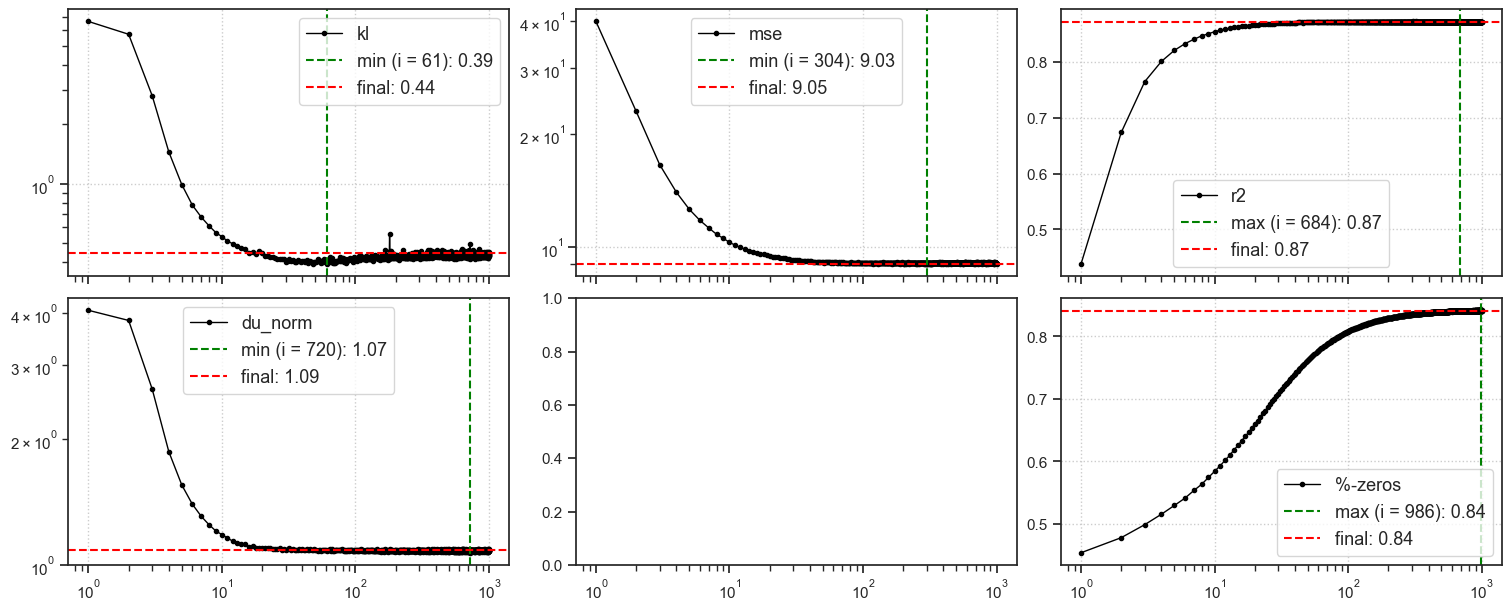

CPU times: user 2min 9s, sys: 1.12 s, total: 2min 10s
Wall time: 2min 10s


In [47]:
%%time


results = tr.analysis(
    dl='vld',
    t_total=1000,
)
_ = plot_convergence(results, color='k')

## Poisson + MNIST + MLP

- recon: ```prob``` + ```optim_sigma```
- Low t_train: 8
- mid beta: 4/8

In [3]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs('MNIST', model_type, 'ngd|mlp')

t_train = 8

cfg_vae['t_train'] = t_train
cfg_vae['kl_beta'] = 4/8 * t_train

cfg_vae['track_stats'] = True

In [4]:
cfg_vae['recon_mode'] = 'prob'
cfg_vae['optim_sigma'] = True

### Make model + trainer

In [5]:
dec_clamp_val = 1.15
np.exp(-2 * dec_clamp_val), np.exp(2 * dec_clamp_val)

(0.10025884372280375, 9.974182454814718)

In [6]:
model = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
model.cfg.set_clamp_val('dec', dec_clamp_val)

In [7]:
tr = Trainer(model, ConfigTrain(**cfg_tr), device=device)
tr.n_iters

120000

### Print info

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  567.1 K   |
|     ———     |    ———     |
|    layer    |  567.1 K   |
+-------------+------------+

poisson_MNIST_t-8_b-4_k-128_prob_<ngd|mlp>
b200-ep400-lr(0.002)_temp(0.05)_gr(50)_(2025_06_03,18:07)

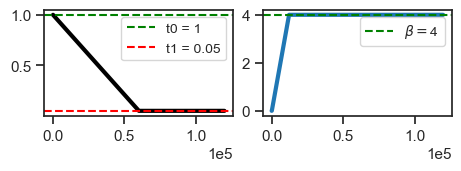

In [8]:
model.print()
tr.print()
tr.show_schedules()

In [9]:
model.layer.n_exp

tensor([50, 50, 50, 50, 50, 50, 50, 50], device='cuda:1', dtype=torch.int32)

In [10]:
model.cfg.track_stats

True

In [11]:
print(f"{vars(tr.model.cfg)}\n\n\n{vars(tr.cfg)}")

{'prior_log_dist': 'uniform', 'clamp_prior': -2, 't_train': 8, 'kl_beta': 4.0, 'n_latents': 128, 'enc_type': 'ngd',
'dec_type': 'mlp', 'recon_mode': 'prob', 'dataset': 'MNIST', 'dataset_name': 'MNIST', 'feeder': 'stationary', 
'feeder_cfg': {}, 'input_sz': (1, 28, 28), 'shape': (-1, 1, 28, 28), 'init_dist': 'normal', 'init_scale': 0.0001, 
'clamp_vals': {'u': (7.0,), 'du': (5.0,), 'dec': 1.15}, 'optim_sigma': True, 'stochastic': True, 'fit_prior': True,
'seed': 0, 'track_stats': True, 'base_dir': '/home/hadi/Projects/PoissonVAE', 'data_dir': '/home/hadi/Datasets', 
'runs_dir': '/home/hadi/Projects/PoissonVAE/runs/poisson_MNIST_t-8_b-4_k-128_prob_<ngd|mlp>', 'mods_dir': 
'/home/hadi/Projects/PoissonVAE/models/poisson_MNIST_t-8_b-4_k-128_prob_<ngd|mlp>', 'results_dir': 
'/home/hadi/Projects/PoissonVAE/results'}


{'lr': 0.002, 'epochs': 400, 'batch_size': 200, 'dataset_kws': None, 'warm_restart': 0, 'warmup_portion': 0.005, 
'optimizer': 'adamax_fast', 'optimizer_kws': {'weight_decay': 0.001, 'betas': (0.9, 0.999), 'eps': 1e-08}, 
'scheduler_type': 'cosine', 'scheduler_kws': {'T_max': 398.0, 'eta_min': 1e-05}, 'ema_rate': None, 'grad_clip': 50,
'chkpt_freq': 20, 'eval_freq': 20, 'log_freq': 10, 'kl_beta_min': 0.0001, 'kl_const_portion': 0.001, 
'kl_anneal_portion': 0.1, 'temp_anneal_portion': 0.5, 'temp_anneal_type': 'lin', 'temp_start': 1.0, 'temp_stop': 
0.05}

### Fit model

In [12]:
tr.train('gold-prob-optim-sigma')

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


Warning: Could not save code info: Reference at 'refs/heads/main' does not exist

Warning: Could not save notebook info: Can't identify the notebook path.

epoch # 400, avg loss: -56.034: 100%|███████| 400/400 [2:24:04<00:00, 21.61s/it]


**Task:** reproduce this while gradually updating the code

**Conclusion:** 

In [13]:
print(model.layer.n_exp)

tensor([21, 39, 57, 60, 61, 63, 64, 65], device='cuda:1', dtype=torch.int32)

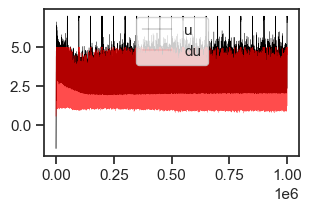

In [14]:
u_max = np.array(tr.model.stats['u_max'])
du_max = np.array(tr.model.stats['du_max'])

fig, ax = create_figure()
ax.plot(u_max, color='k', label='u', lw=0.2)
ax.plot(du_max, color='r', label='du', alpha=0.7, lw=0.2)
ax.legend()
plt.show()

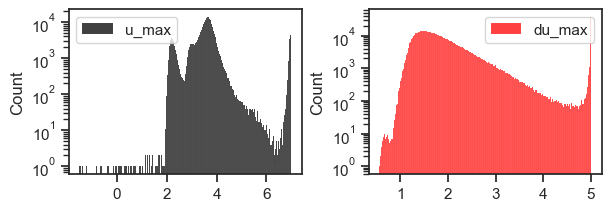

In [15]:
fig, axes = create_figure(1, 2)
sns.histplot(tr.model.stats['u_max'], color='k', label='u_max', ax=axes[0])
sns.histplot(tr.model.stats['du_max'], color='r', label='du_max', ax=axes[1])
for ax in axes.flat:
    ax.set(yscale='log')
add_legend(axes)
plt.show()

100%|███████████████████████████████████| 3/3 [00:37<00:00, 12.52s/it]


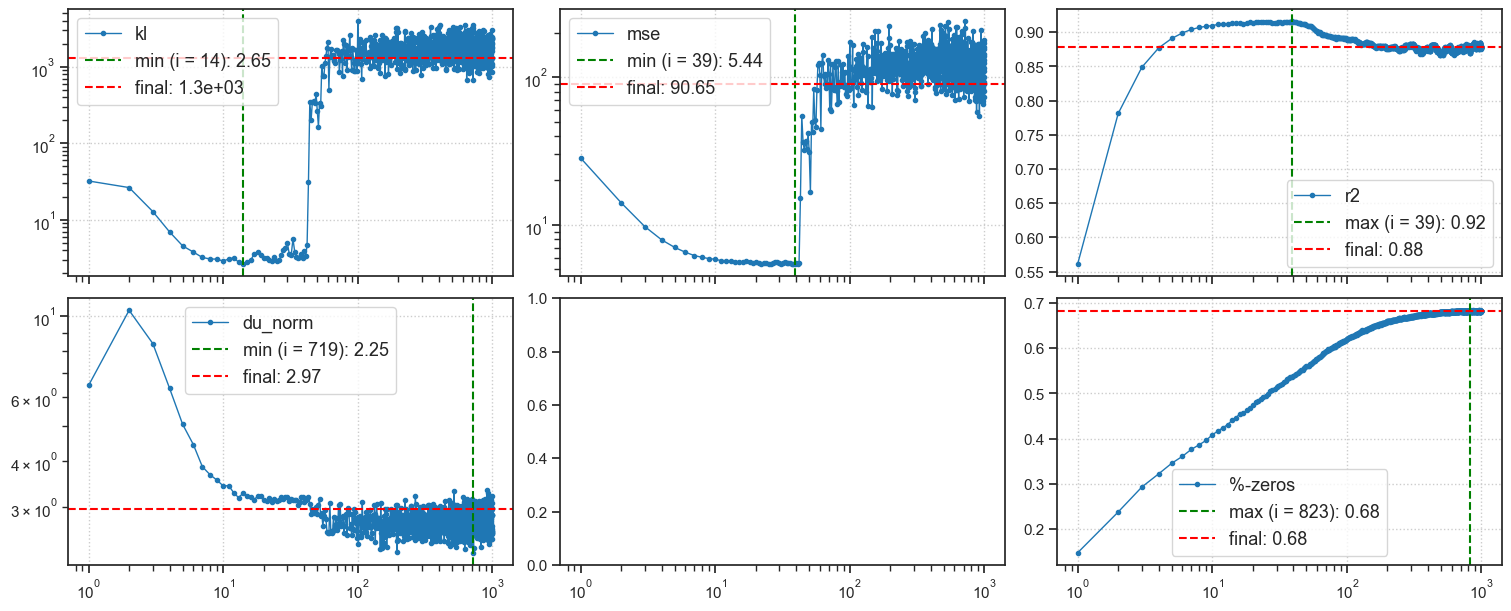

CPU times: user 39.3 s, sys: 60.2 ms, total: 39.3 s
Wall time: 39.3 s


In [16]:
%%time


results = tr.analysis(
    dl='vld',
    t_total=1000,
    n_data_batches=3,
)
_ = plot_convergence(results, color='C0')

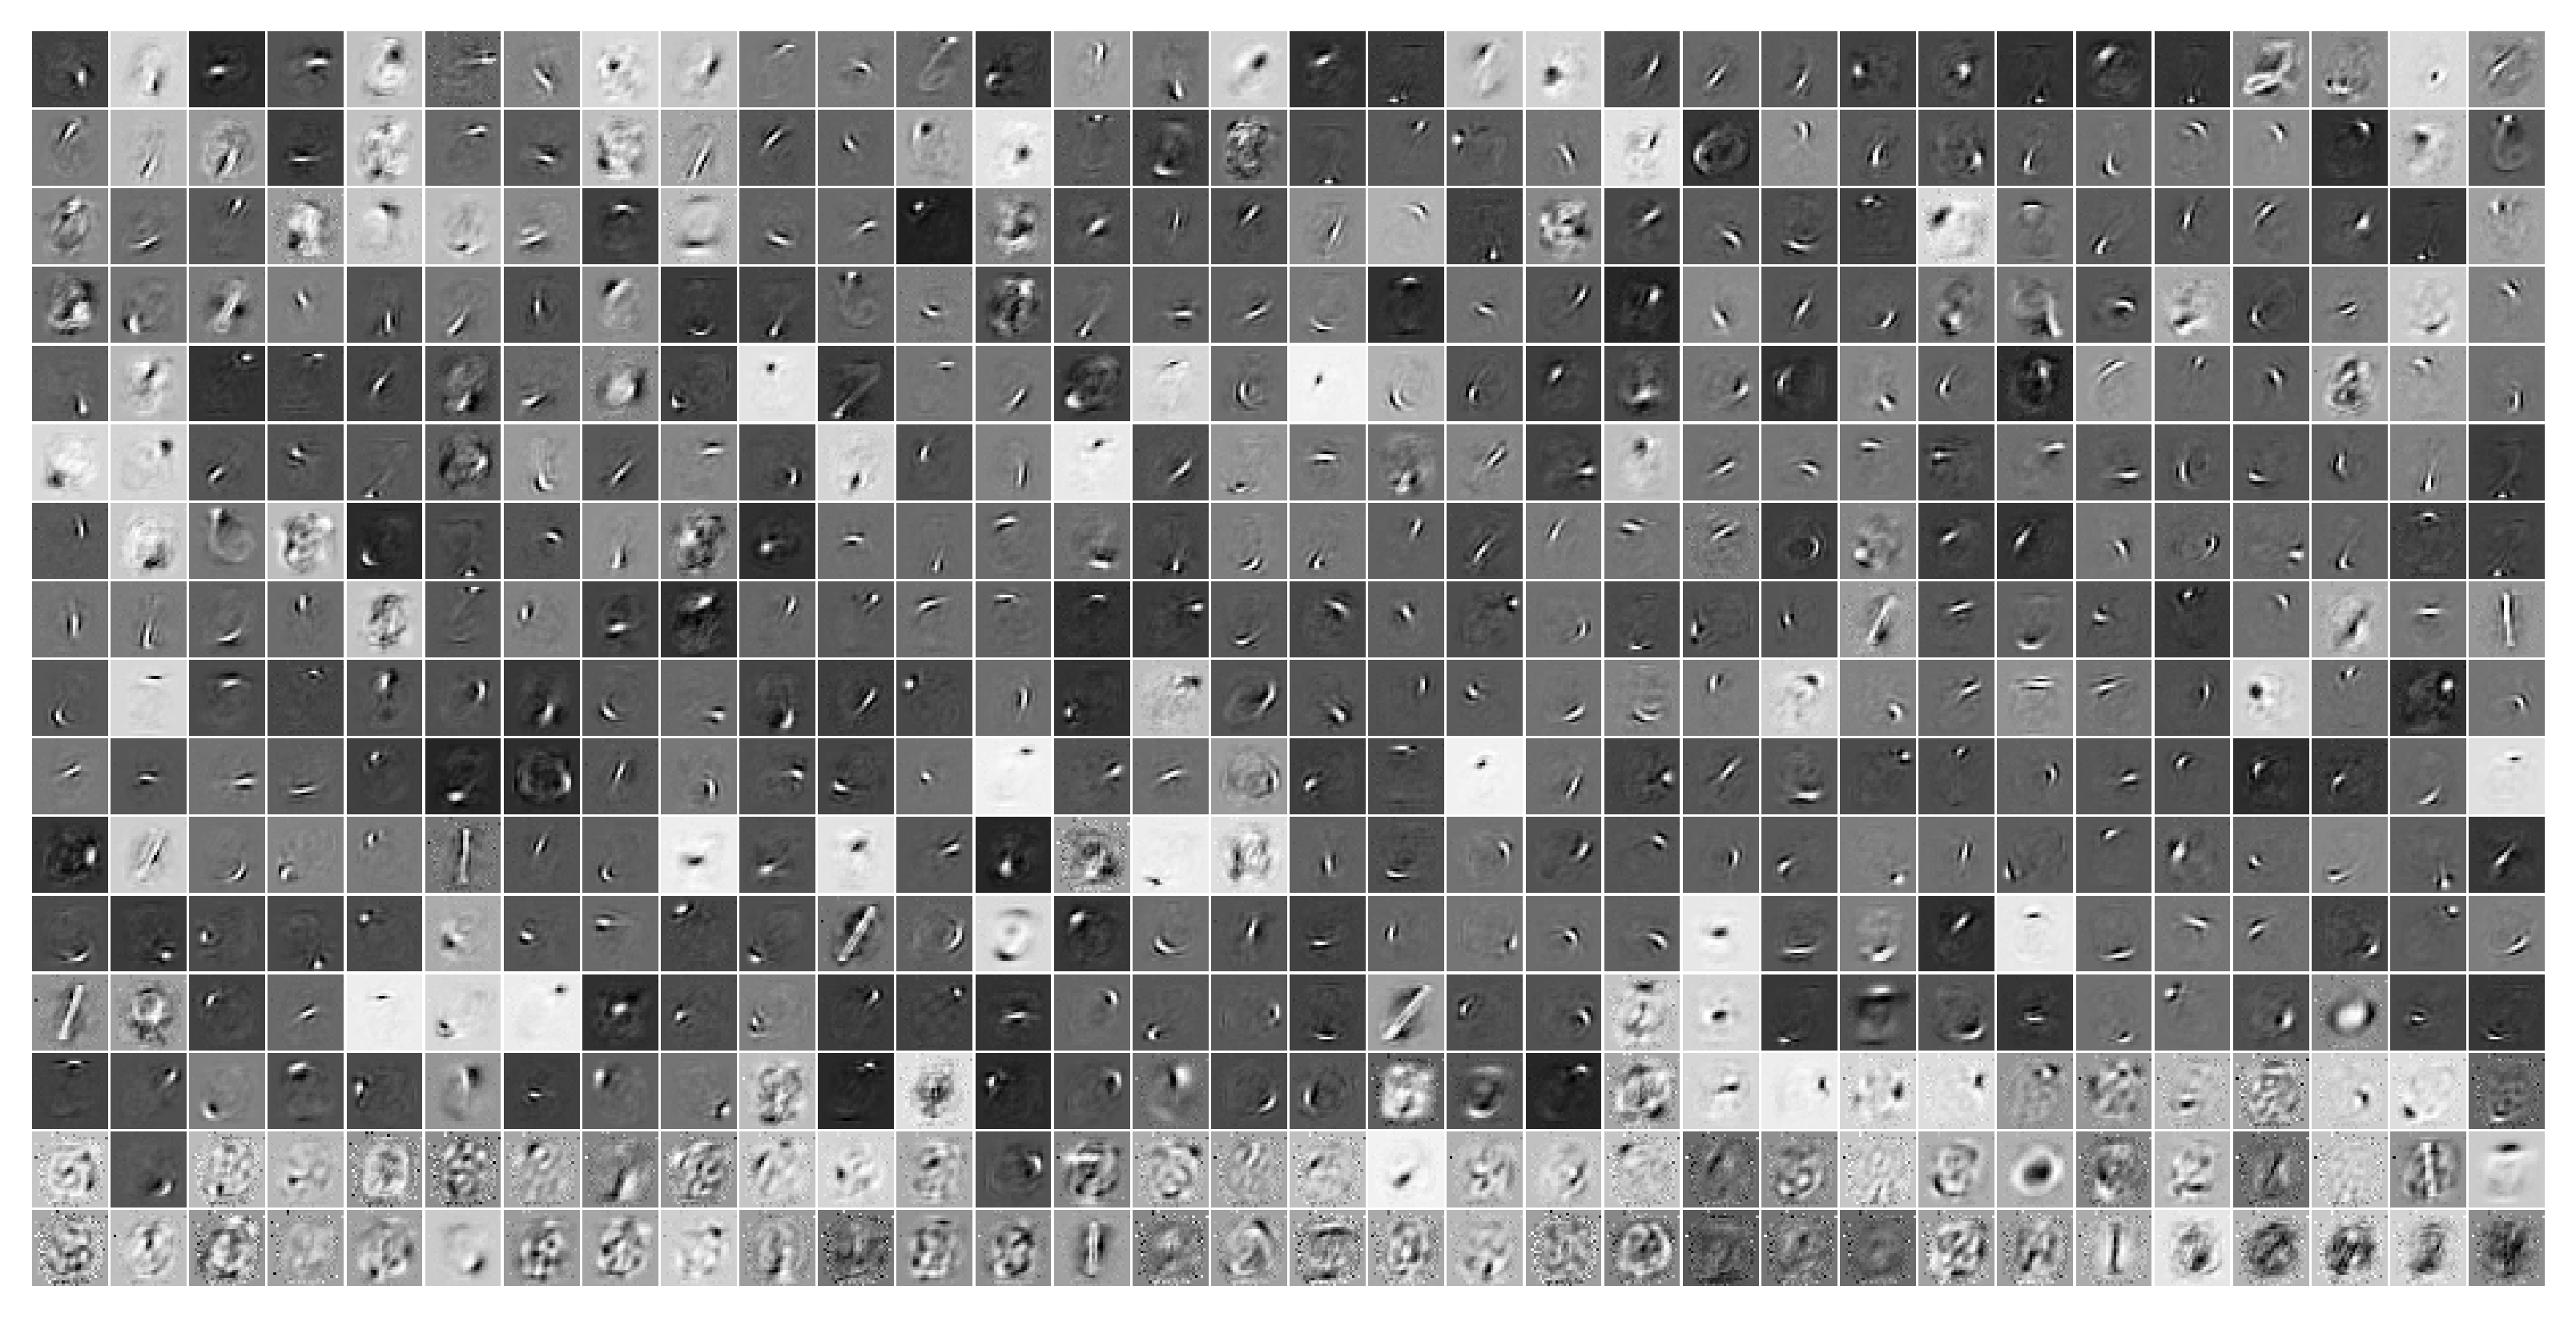

In [17]:
w = tr.model.layer.get_weight()
norms = tonp(torch.linalg.vector_norm(w, dim=1))
tr.model.show(order=np.argsort(norms), dpi=400, pad=1);

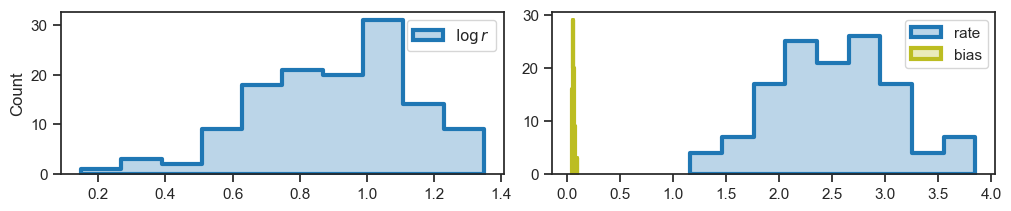

In [18]:
log_rate = tonp(tr.model.layer.u_init[0].squeeze())
bias = tonp(tr.model.layer.log_bias.exp().squeeze())

fig, axes = create_figure(1, 2, (10, 2))
kws = dict(fill=True, lw=3, alpha=0.3, ax=axes[0])
sns.histplot(log_rate, color='C0', element='step', label=r'$\log r$', **kws)

kws = dict(fill=True, lw=3, alpha=0.3, ax=axes[1])
sns.histplot(np.exp(log_rate), color='C0', element='step', label='rate', **kws)
sns.histplot(bias, color='C8', element='step', label='bias', **kws)

axes[1].set(ylabel='')
add_legend(axes)

plt.show()

In [19]:
dead = (log_rate < -1) | (log_rate > 2)
dead.sum(), (~dead).sum(), dead.sum() / len(dead)

(0, 128, 0.0)

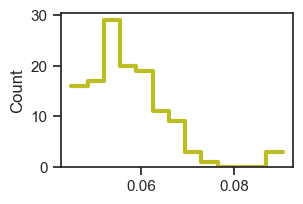

In [20]:
histplot(bias, color='C8', lw=3)
plt.show()

In [21]:
(bias > 0).mean()

1.0

In [22]:
bias[dead]

array([], dtype=float32)

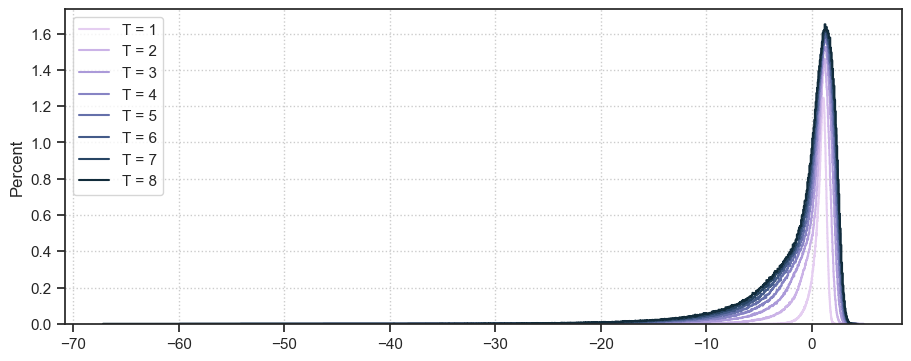

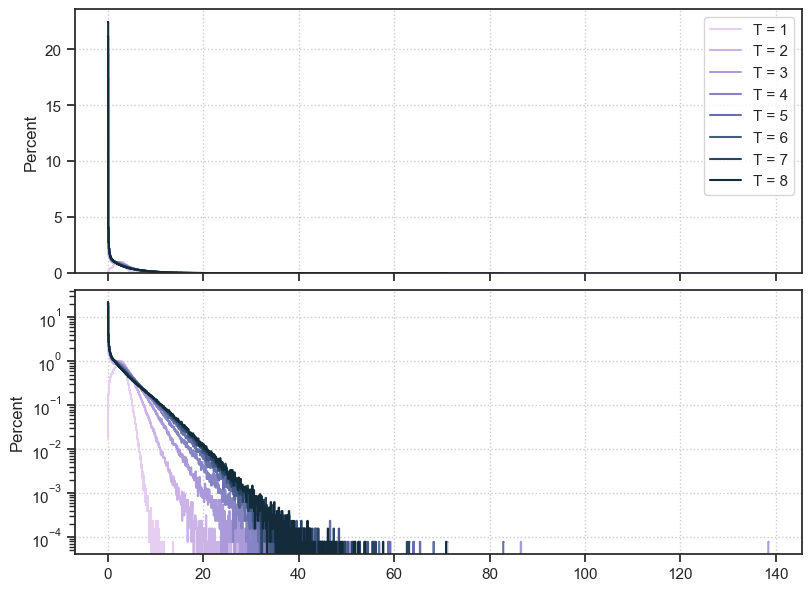

In [23]:
mult = 1

results = tr.xtract_ftr(
    t_total=tr.model.cfg.t_train * mult,
    save_freq=mult,
    n_data_batches=10,
    data_batch_sz=2000,
    verbose=False,
)


fig, ax = create_figure(1, 1, (9, 3.5))
pal = get_cubehelix_palette(len(results['times']), start=2.5)

for i, t in enumerate(results['times']):
    sns.histplot(
        results['state_0'][:, i].ravel(),
        stat='percent',
        element='step',
        fill=False,
        color=pal[i],
        label=f"T = {t}",
        ax=ax,
    )
ax.legend(loc='upper left')
ax.grid()
plt.show()


fig, axes = create_figure(2, 1, (8, 5.8), sharex='col')
for i, t in enumerate(results['times']):
    for ax in axes.flat:
        sns.histplot(
            np.exp(results['state_0'][:, i].ravel()),
            stat='percent',
            element='step',
            fill=False,
            color=pal[i],
            label=f"T = {t}",
            ax=ax,
        )
axes[0].legend()
axes[1].set(yscale='log')
add_grid(axes)
plt.show()

In [24]:
pal

[[0.8975507056831679, 0.8094812603307622, 0.9465577040964425],
 [0.79560472689218, 0.7025635211553574, 0.906794768375293],
 [0.6686407796183966, 0.6049991340541501, 0.8494437689559234],
 [0.5300158317387482, 0.5177020247219766, 0.7688253061707515],
 [0.3958415626832449, 0.4388270462167934, 0.6665458619228831],
 [0.26577992459661565, 0.3565507347057864, 0.5356429755155622],
 [0.158519102797742, 0.271866265196377, 0.39112323360373646],
 [0.07235872150128392, 0.17287618251766537, 0.23013648857700542]]

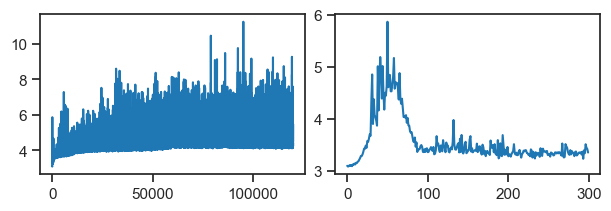

In [25]:
grad = np.array(list(tr.stats['grad'].values()))

fig, axes = create_figure(1, 2)
axes[0].plot(np.log(grad))
axes[1].plot(np.log(grad)[:300])
plt.show()

In [26]:
(grad > 100).sum()

30033

100%|█████████████████████████████████| 50/50 [10:11<00:00, 12.24s/it]


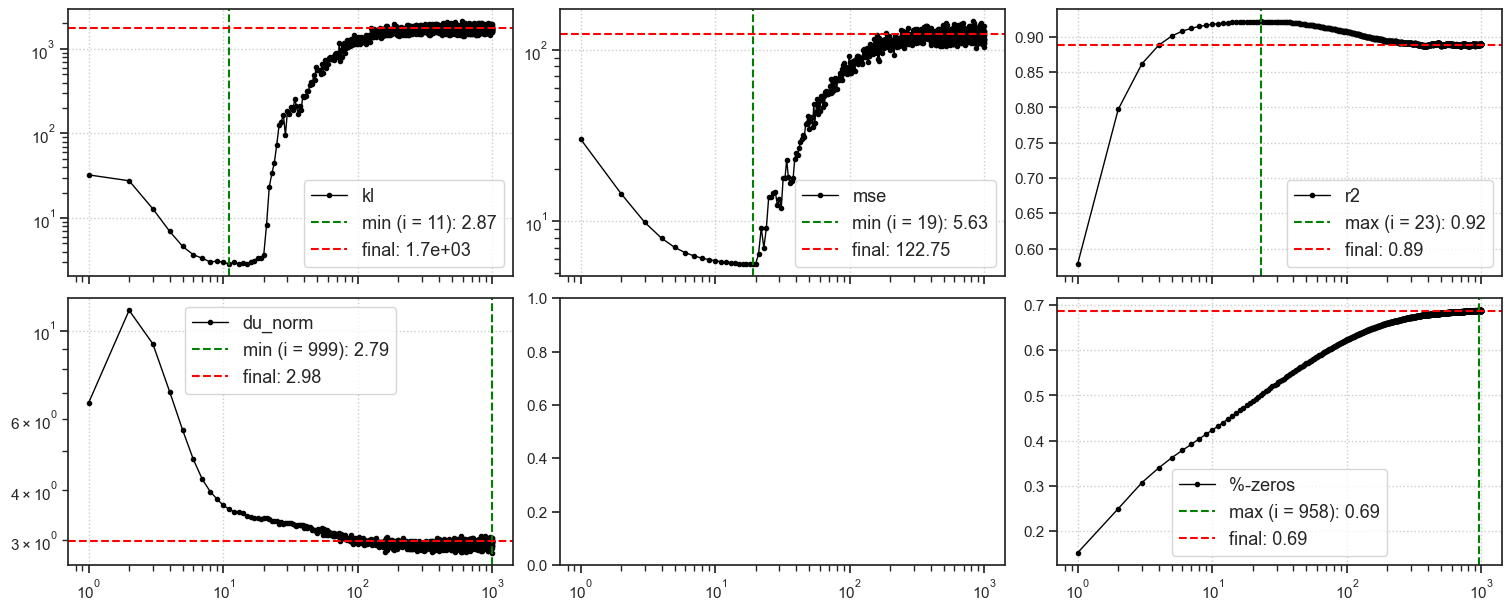

CPU times: user 10min 18s, sys: 1.48 s, total: 10min 19s
Wall time: 10min 19s


In [27]:
%%time


results = tr.analysis(
    dl='vld',
    t_total=1000,
)
_ = plot_convergence(results, color='k')